### Homework 2: Exploratory data analysis and visualization

UIC CS 418, Fall 2025

_According to the **Academic Integrity Policy** of this course, all work submitted for grading must be done individually, unless otherwise specified. While we encourage you to talk to your peers and learn from them, this interaction must be superficial with regards to all work submitted for grading. This means you cannot work in teams, you cannot work side-by-side, you cannot submit someone else’s work (partial or complete) as your own. In particular, note that you are guilty of academic dishonesty if you extend or receive any kind of unauthorized assistance. Absolutely no transfer of program code between students is permitted (paper or electronic), and you may not solicit code from family, friends, or online forums. Other examples of academic dishonesty include emailing your program to another student, copying-pasting code from the internet, working in a group on a homework assignment, and allowing a tutor, TA, or another individual to write an answer for you. Academic dishonesty is unacceptable, and penalties range from failure to expulsion from the university; cases are handled via the official student conduct process described at https://dos.uic.edu/conductforstudents.shtml._

_This homework may be completed in pairs. You may tag your teammate in Gradescope upon submission. Please write the name of a student who led the completion of a particular question at the start of that question._

There are four parts in this homework. The first one (Q0) is a practice introduction to `matplotlib` (5%). The second (Q1.1-Q1.5) is a guided exploration of a google_play dataset (40%). The third one (Q2.0-Q2.4) is a self-guided exploration of a dataset on religious composition of the world’s migrants (45%). The forth one (Q3.1-3.3) is Hypothesis testing practice (10%). You can also earn extra credit of 15%.


## Due Date

This assignment is due at 11:59pm October 15th, 2025. 


### What and How to Submit

You need to complete all code and answer all questions denoted by **Q#** (each one is under a bike image) in this notebook. Then,  you need to **execute** each cell so that the output is visible. **Otherwise, if the output is not visible, its correctness cannot be immediately verified and the question will be marked as incorrect**. When you are done, you should export **hw2.ipynb** with your answers as a PDF file, upload the PDF file to *Homework 2 - Written Part* on Gradescope, tagging each question. You need to upload a completed Jupyter notebook (hw2.ipynb file) to *Homework 2 - Code* on Gradescope. If one of these two parts (written and code) is missing, you will lose 50%.

Once again, make sure you check that your pdf file includes all parts of your solution **(including the outputs)**. We recommend using the browser (not jupyter) for saving the pdf. For Chrome on a Mac, this is under *File->Print...->Open PDF in Preview* and when the PDF opens in Preview you can use *Save...* to save it. If that doesn't work, click File->Save and Export Notebook As->HTML. Then, open the HTML in your browser and select File->Print... and save it as a PDF.

**Important:**

After you upload the PDF on Gradescope, be sure to correctly mark **all** pages corresponding to every answer (from the page containing the question number up to the page that contains the last line of code or text from that question. Incorrectly marked questions slow down the grading, so there is a **0.5 point penalty** for every unmarked or incorrectly marked question. Please let the teaching staff know if you need any help.


#### Autograding

We will not use autograding for this homework assignment. However, you still need to submit the Python notebook (.ipynb file) to the *Homework 2 - Code* submission.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import norm

sns.set_style('whitegrid')

# Practice: `matplotlib` (5%)

[`matplotlib`][mpl] is the most widely used plotting library available for Python. It comes with a good amount of out-of-the-box functionality and is highly customizable. Most other plotting libraries in Python provide simpler ways to generate complicated `matplotlib` plots, including `seaborn`, so it's worth learning a bit about `matplotlib` now.

Notice how all of our notebooks have lines that look like:

	%matplotlib inline
	import matplotlib.pyplot as plt
	
The `%matplotlib inline` magic command tells `matplotlib` to render the plots
directly onto the notebook (by default it will open a new window with the plot). If your plot still doesn't show up, add `plt.show()` at the bottom to explicitly tell matplotlib to render the plot.

Then, the `import` line lets us call `matplotlib` functions using `plt.<func>`

Here's a graph of `cos(x)` from 0 to 2 * pi.

[mpl]: http://matplotlib.org/

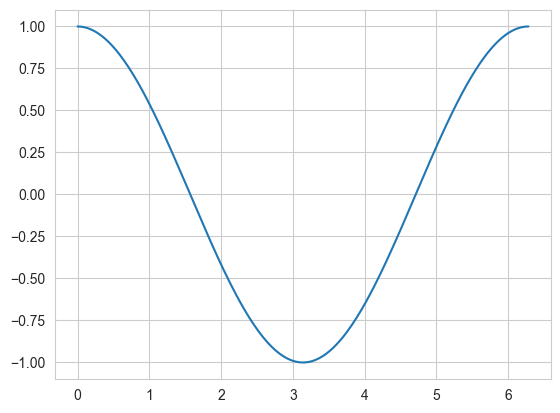

In [2]:
# Set up (x, y) pairs from 0 to 2*pi
xs = np.linspace(0, 2 * np.pi, 300)
ys = np.cos(xs)

# plt.plot takes in x-values and y-values and plots them as a line
plt.plot(xs, ys)
plt.show()

`matplotlib` also conveniently has the ability to plot multiple things on the same plot. Just call `plt.plot` multiple times in the same cell:

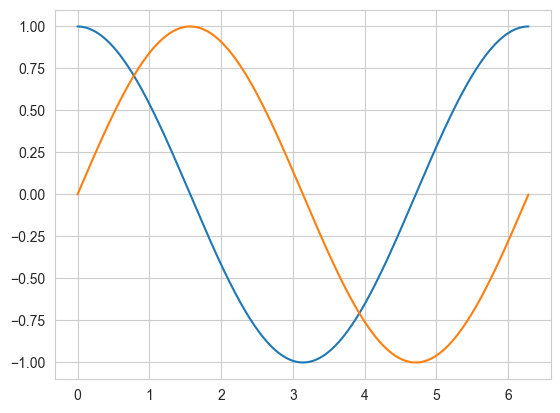

In [3]:
plt.plot(xs, ys)
plt.plot(xs, np.sin(xs))
plt.show()

That plot looks pretty nice but isn't presentation-ready. Luckily, `matplotlib` has a wide array of plot customizations.


## Q0 (5%):

Skim through the first part of the tutorial at https://github.com/rougier/matplotlib-tutorial to create the plot below. There is a lot of extra information there which we suggest
you read on your own time. For now, just look for what you need to make the plot.

Specifically, you'll have to change the x and y limits, add a title, and add a legend.

![](q1.png)

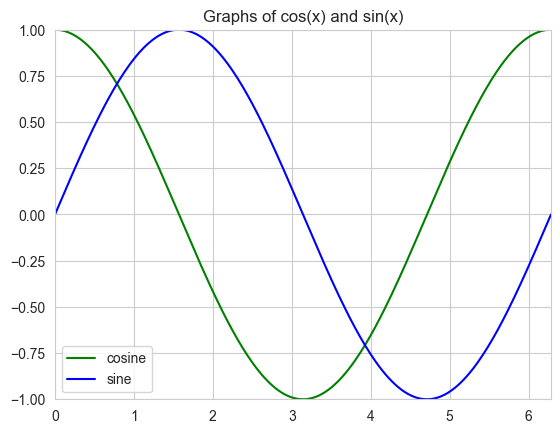

In [4]:
# Here's the starting code from last time. Edit / Add code to create the plot above.
plt.plot(xs, ys, color='green', label='cosine')
plt.plot(xs, np.sin(xs), color='blue', label='sine')
plt.title("Graphs of cos(x) and sin(x)")
plt.xlim(0, 2 * np.pi)
plt.ylim(-1.0, 1.0)
plt.legend()
plt.show()

# Part 1: Guided EDA of google play store apps (40%)

You will be performing some basic EDA (exploratory data analysis) on Google Play Store apps data. Feel free to edit code for clearning the data.


In [5]:
google_play = pd.read_csv('googleplaystore.csv')

# You may drop rows where Rating is NaN to avoid issues 
google_play = google_play.dropna(subset=['Rating'])
google_play['Rating'] = pd.to_numeric(google_play['Rating'], errors='coerce')
google_play['Reviews'] = pd.to_numeric(google_play['Reviews'], errors='coerce')
google_play['Last Updated'] = pd.to_datetime(google_play['Last Updated'], errors='coerce')
google_play = google_play[google_play['Category'] != '1.9']

In [6]:
google_play.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159.0,19M,"10,000+",Free,0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510.0,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644.0,25M,"50,000,000+",Free,0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967.0,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up


## Q1.1 (8%):
Explore the `google_play` dataframe to answer the following questions.

What is the data granularity?
What time range is represented here? Write code in the cell below to perform your exploration.

In [7]:
google_play.info()
print("\nNumber of rows:", len(google_play))
print("Unique apps:", google_play['App'].nunique())

print("\nEarliest update date:", google_play['Last Updated'].min())
print("Latest update date:", google_play['Last Updated'].max())

<class 'pandas.core.frame.DataFrame'>
Index: 9366 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             9366 non-null   object        
 1   Category        9366 non-null   object        
 2   Rating          9366 non-null   float64       
 3   Reviews         9366 non-null   float64       
 4   Size            9366 non-null   object        
 5   Installs        9366 non-null   object        
 6   Type            9366 non-null   object        
 7   Price           9366 non-null   object        
 8   Content Rating  9366 non-null   object        
 9   Genres          9366 non-null   object        
 10  Last Updated    9366 non-null   datetime64[ns]
 11  Current Ver     9362 non-null   object        
 12  Android Ver     9364 non-null   object        
dtypes: datetime64[ns](1), float64(2), object(10)
memory usage: 1.0+ MB

Number of rows: 9366
Unique apps: 8196

Earl

The data granularity is the level of individual apps in the Google Play Store. In this dataset, each row represents a unique app entry and the associated metadata for that entry. There are 9,366 rows in the dataset containing 8,196 unique apps. The time range represented is from May 21, 2010 to August 8, 2018.

## Using `pandas` to plot

`pandas` provides useful methods on dataframes. For simple plots, we prefer to
just use those methods instead of the `matplotlib` methods since we're often
working with dataframes anyway. The syntax is:

    dataframe.plot.<plotfunc>

Where the `<plotfunc>` is one of the functions listed under _Plotting_ here: https://pandas.pydata.org/pandas-docs/stable/reference/frame.html

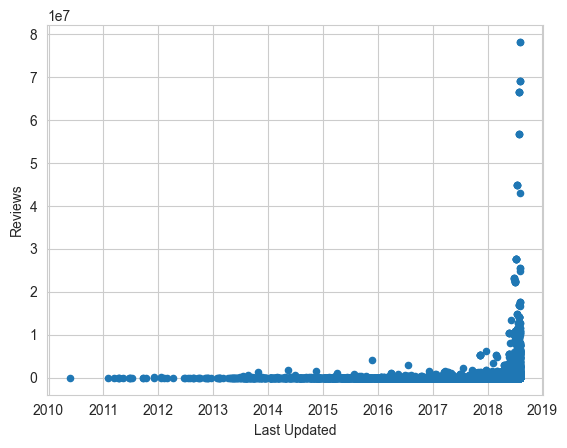

In [8]:
# This plot shows the trend of app ratings over time

google_play.plot.scatter(x='Last Updated', y='Reviews')
plt.show()

## `seaborn`

Now, we'll learn how to use the [`seaborn`][sns] Python library. `seaborn`
is built on top of `matplotlib` and provides many helpful functions
for statistical plotting that `matplotlib` and `pandas` don't have.

Generally speaking, we'll use `seaborn` for more complex statistical plots,
`pandas` for simple plots (eg. line / scatter plots), and
`matplotlib` for plot customization.

Nearly all `seaborn` functions are designed to operate on `pandas`
dataframes. Most of these functions assume that the dataframe is in
a specific format called *long-form*, where each column of the dataframe
is a particular feature and each row of the dataframe a single datapoint.

For example, this dataframe is long-form:

```
   country year avgtemp
 1  Sweden 1994       6
 2 Denmark 1994       6
 3  Norway 1994       3
 4  Sweden 1995       5
 5 Denmark 1995       8
 6  Norway 1995      11
 7  Sweden 1996       7
 8 Denmark 1996       8
 9  Norway 1996       7
```

But this dataframe of the same data is not:

```
   country avgtemp.1994 avgtemp.1995 avgtemp.1996
 1  Sweden            6            5            7
 2 Denmark            6            8            8
 3  Norway            3           11            7
```

Note that the `google_play` dataframe is long-form.

For more about long-form data, see https://stanford.edu/~ejdemyr/r-tutorials/wide-and-long.
For now, just remember that we typically prefer long-form data and it makes plotting using
`seaborn` easy as well.

[sns]: http://seaborn.pydata.org/index.html

We can create the same plot as the `dataframe.plot` above using the following `seaborn` function: `sns.lineplot`. Notice that instead of calling the plot function on dataframe object, here we pass it as a parameter to the function:

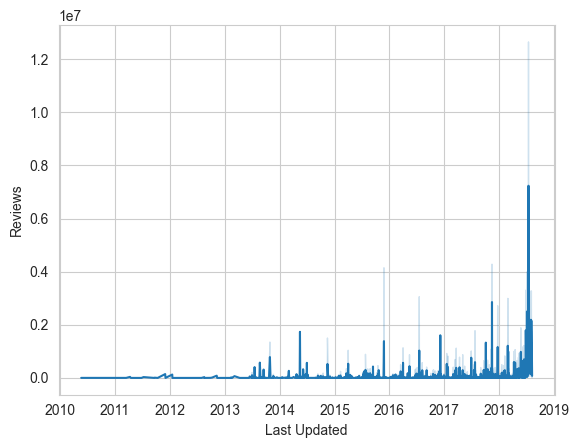

In [9]:
# You can create a plot similar to the one above using the following seaborn syntax
# Note that the seaborn plot is a bit different and requires some customizations (more on this later)
sns.lineplot(x="Last Updated", y="Reviews", data=google_play)
plt.show()

## Q1.2 (8%):

Use seaborn's barplot function to make a bar chart showing the average rating for each app category over the entire `google_play` dataset. Here's a link to the seaborn API:

Here's a link to the seaborn API: http://seaborn.pydata.org/api.html

See if you can figure it out by reading the docs. 

What trends do you notice? What do you suppose causes these trends?

Notice that `barplot` draws error bars for each category. It uses bootstrapping to make those.

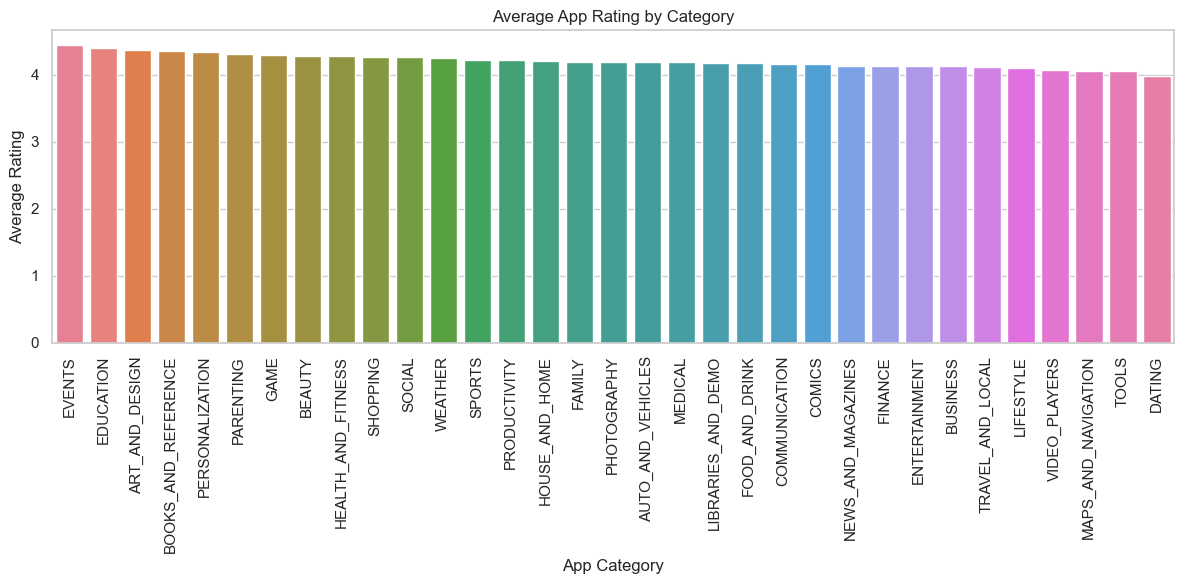

In [25]:
sns.set(style="whitegrid")

sorted_data = google_play.groupby('Category', as_index=False)['Rating'].mean()
sorted_data = sorted_data.sort_values('Rating', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Category', y='Rating', data=sorted_data, hue="Category")

plt.xticks(rotation=90)
plt.title('Average App Rating by Category')
plt.xlabel('App Category')
plt.ylabel('Average Rating')

plt.tight_layout()
plt.show()

Each app category had ratings above 4 stars with the exception of dating, indicating that most apps on the Google Play Store are getting high reviews. The categories Events, Education, and Art and Design have the highest reviews with Maps and Navigation, Tools, and Dating scoring the lowest. These categories scoring the lowest could be because the apps in these categories are prone to causing the highest level of frustration with the users. When you are driving for example, you need your navigation app to work perfectly so you can focus on the road. If there is any issue, it could prompt users to leave a bad review. Dating apps could also be prone to bad user reviews by consumers that have bad experiences with the people that they meet while using the app.

## Q1.3 (8%):

Now for a fancier plot that `seaborn` makes really easy to produce.

Use the `displot` function to plot a histogram of all the ratings in the `google_play` dataset. Can you fit a curve to the histogram of the data using `seaborn`? You just need to tune `kde` and `stat` paramaters to the `displot` function. Fancy!

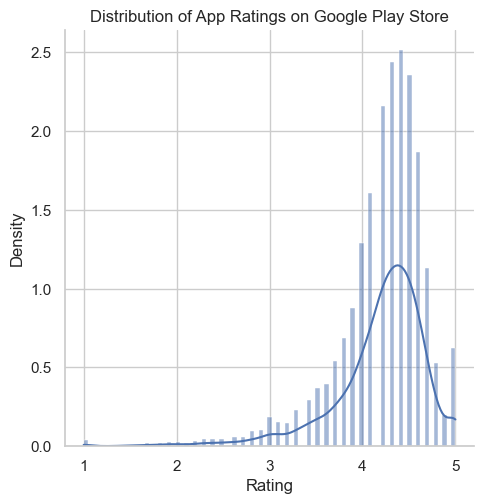

In [11]:
sns.displot(
    data=google_play,
    x='Rating',
    kde=True,
    stat='density'
)

plt.title('Distribution of App Ratings on Google Play Store')
plt.xlabel('Rating')
plt.ylabel('Density')

plt.show()

## Q1.4 (8%):

Use `seaborn` to make side-by-side boxplots of the number of reviews and app size for the apps in the `google_play` dataset. The `boxplot` function will plot all the columns of the dataframe you pass in.

Note that, you may need to pre-process the 'Size' column for numeric analysis. Hint: you may want to convert kb to mb.

Once you make the plot, you'll notice that there are many outliers that make the plot hard to see. To mitigate this, change the y-scale to be logarithmic.

That's a plot customization so you'll use `matplotlib`. The `boxplot` function returns a `matplotlib` Axes object which represents a single plot and has a `set_yscale` function.

The result (after customization) should look like:

![](q1-4.png)

Revisiting Q1.1 on data granularity, what is more suitable text for `ylabel` here than `Number of reviews`?

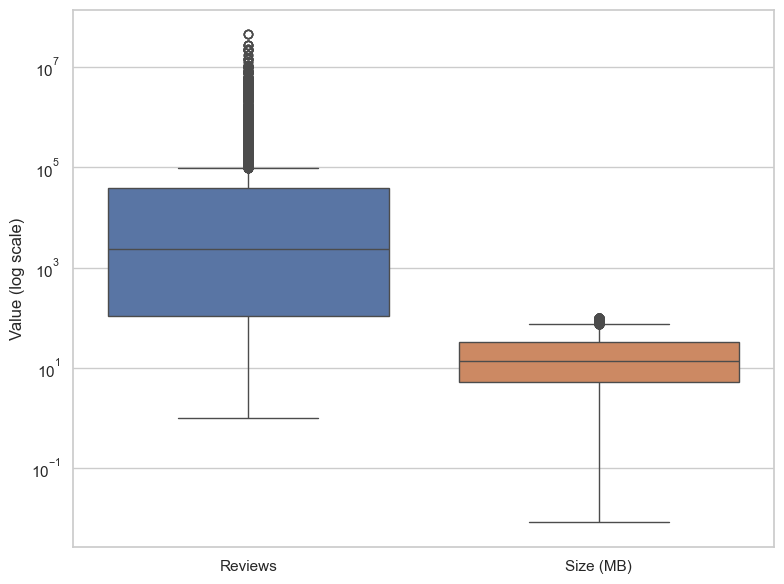

In [12]:
def convert_size(value):
    if pd.isna(value):
        return None

    value = str(value).strip()

    if value.lower() == 'varies with device' or value == '':
        return None

    if value.endswith('M') or value.endswith('m'):
        try:
            return float(value[:-1]) 
        except ValueError:
            return None
    elif value.endswith('k') or value.endswith('K'):
        try:
            return float(value[:-1]) / 1024
        except ValueError:
            return None
    else:
        try:
            return float(value)
        except ValueError:
            return None

google_play['Size_MB'] = google_play['Size'].apply(convert_size)
boxplot_data = google_play[['Reviews', 'Size_MB']].dropna()

plt.figure(figsize=(8, 6))
axis = sns.boxplot(data=boxplot_data.rename(columns={'Size_MB': 'Size (MB)'}))

axis.set_yscale('log')

axis.set_ylabel('Value (log scale)')

plt.tight_layout()
plt.show()

## Q1.5 (8%):

Let's take a closer look at the number of reviews vs. rating.

Use the `lmplot` function to make a scatterplot. Put the number of reviews on the x-axis and the rating on the y-axis.
Each point should correspond to a single row in your `google_play` dataframe. Notice that `seaborn` automatically fits a line of best fit to the plot. Does that line seem to be relevant?

You should note that `lmplot` allows you to pass in `fit_reg=False` to avoid plotting lines of best fit when you feel they are unnecessary or misleading.

There seem to be two main groups in the scatterplot. Let's see if we can separate them out. Use `lmplot` to make the scatterplot again. This time, use the `hue` parameter to color points for free apps differently from paid apps.

Note that, you may need to pre-process the 'Type' column, only keep rows where 'Type' is "Free" or "Paid".

You should get something that looks like:

![](q1-5.png)


In [13]:
# Hint: Use log number of reviews makes it easier to observe the app data
# so you may want to use 'Log_Reviews' for this question
google_play['Log_Reviews'] = np.log1p(google_play['Reviews'])

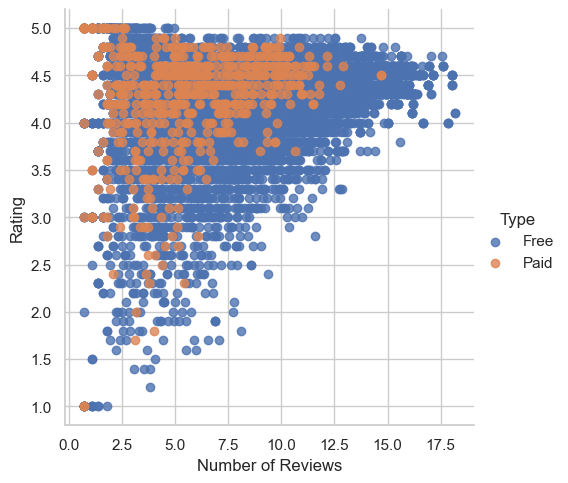

In [14]:
sns.lmplot(
    data=google_play,
    x='Log_Reviews', y='Rating',
    hue='Type',
    fit_reg=False
)
plt.xlabel('Number of Reviews')
plt.ylabel('Rating')

plt.show()

## Want to learn more?

We recommend checking out the `seaborn` tutorials on your own time. http://seaborn.pydata.org/tutorial.html

The `matplotlib` tutorial we linked in Question 1 is also a great refresher on common `matplotlib` functions: https://www.labri.fr/perso/nrougier/teaching/matplotlib/

Here's a great blog post about the differences between Python's visualization libraries:
https://dansaber.wordpress.com/2016/10/02/a-dramatic-tour-through-pythons-data-visualization-landscape-including-ggplot-and-altair/


# Part 2: Self-directed EDA of Religious composition of the world’s migrants (45%)

The last part is intentionally more open-ended and will be graded on the completeness of the plot(s) produced and the insights you gain from them.  The goal here is for you to thoroughly explore a dataset on the religious breakdown of immigrants to, and emigrants from, countries and regions of the world.

_Question 2.0_ is asking you to look at a given visualization and reverse engineer the code that created it. _Question 2.1_ is about _data exploration visualization_ while the other questions are about _data presentation visualization_. Report your three most significant findings (_Q2.2, Q2.3, and Q2.4_). Each finding should have a _visualization headline_  which highlights the main takeaway in 5-15 words, an informative visualization that supports your finding and a _visualization description_, 100-150 words per finding explaining your assumptions and what you have found. For example, the visualization headline could be "?" with the following bar plot visualization:  

<img src="q2-1.png">


The survey data that you will analyze was collected by Pew Research. In order to access it, you need to create an account and download it from [here](https://www.pewresearch.org/dataset/dataset-religious-composition-of-the-worlds-migrants-1990-2020/) (click on "Download Dataset" in upper right corner). The file you will work with is `Incoming and Outgoing Migrant Counts.csv`.

Be sure to consider transformations, subsets, correlations, reference markers, and lines/curves-of-best-fit (as covered in Chapter 6 of PTDS) to reveal the relationship that you are wanting to learn more about.  Also be sure to make plots that are appropriate for the variable types.  For completeness, be explicit about any assumptions you make in your analysis.  An exemplary plot will have:

* A title
* Labelled and appropriately scaled axes
* A legend, if applicable
* A carefully selected color scheme
* A main point, accentuated through design choices



## Q2.0 (10%): Reverse Engineer

Your first step is to load the data from `Incoming and Outgoing Migrant Counts.csv`, and understand what is stored in it. Your assignment is to replicate the bar plot visualization shown above. Notice the labels on x and y axes as well as the legend of the plot to determine the information needed to construct the plot.

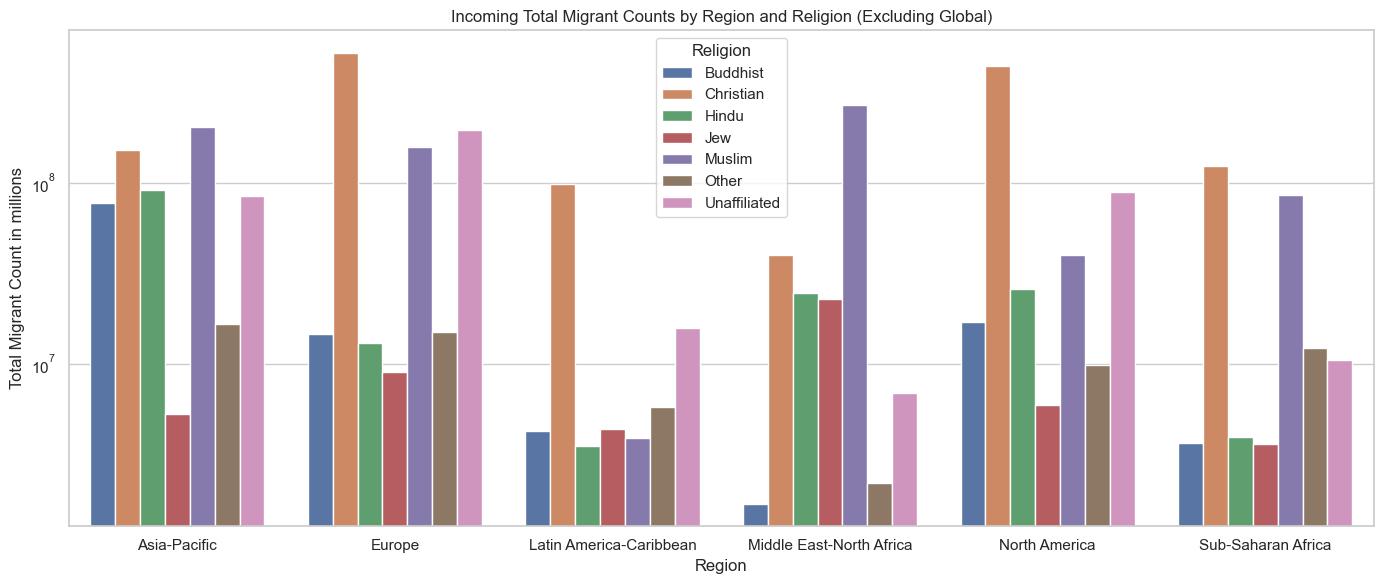

In [15]:
#HINTS
# 1) Read your dataframe with pandas
# 2) Identify what colums are used for plot above
# 3) Filter required rows and columns necessary for plotting above figure
# 4) Pre-process the rows may cause issues
# Hint: there are some values in 'Count' is < 10,000, you can change them to 10,000.
# 4) Use pandas aggregation to group by Region and Religion and sum the migrant counts
# 5) Use seaborn barplot to plot the figure above. Customize with color palette='viridis'
# 6) Add descriptive xlabel, ylabel, and title
# 7) change the y-scale to be logarithmic for better visualization
# 8) Customize legend if necessary
def parse_count(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s.startswith('<'):             
        return 10000.0
    s = s.replace(',', '')            
    return float(s)


migrant_data = pd.read_csv('Incoming and Outgoing Migrant Counts.csv')
# print(migrant_data.columns)
# migrant_data.head()

incoming = migrant_data[(migrant_data['Direction'] == 'Incoming') & (migrant_data['Region'] != 'Global')].copy()

incoming = incoming[incoming['Religion'] != 'All'].copy()

incoming['Count'] = incoming['Count'].apply(parse_count)

incoming.loc[incoming['Count'] < 10000, 'Count'] = 10000

grouped = (incoming.groupby(['Region', 'Religion'], as_index=False)['Count'].sum())

plt.figure(figsize=(14, 6))
sns.barplot(data=grouped, x='Region', y='Count', hue='Religion')
plt.yscale('log')
plt.title('Incoming Total Migrant Counts by Region and Religion (Excluding Global)')
plt.xlabel('Region')
plt.ylabel('Total Migrant Count in millions')
plt.legend(title='Religion')
plt.tight_layout()
plt.show()


## Q2.1 (5%): Initial exploration

Run descriptive statistics on the data by considering the EDA key data properties we covered in class. Write a 100-150 word description of your findings. Based on these statistics or other ideas you have, form hypotheses that guide your EDA and visualizations for the last three questions. You need to show at least one visualization but you are welcome to show more.

In [18]:
print(migrant_data.columns)

migrant_data['Count'] = migrant_data['Count'].apply(parse_count)
migrant_data.loc[migrant_data['Count'] < 10000, 'Count'] = 10000

religion_summary = migrant_data.groupby(['Direction', 'Religion'])['Count'].sum().reset_index()
religion_summary = religion_summary.sort_values(by='Count', ascending=False)
print(religion_summary)
print()
print()

region_summary = migrant_data.groupby(['Direction', 'Region'])['Count'].sum().reset_index()
region_summary = region_summary.sort_values(by='Count', ascending=False)
print(region_summary)
print()
print()

year_summary = migrant_data.groupby(['Direction', 'Year'])['Count'].sum().reset_index()
year_summary = year_summary.sort_values(by='Year', ascending=True)
print(year_summary)
print()
print()

Index(['Direction', 'Year', 'Country', 'Religion', 'Count', 'Percent',
       'Region', 'level', 'countrycode'],
      dtype='object')
   Direction      Religion         Count
8   Outgoing           All  4.286680e+09
0   Incoming           All  4.286600e+09
2   Incoming     Christian  2.049870e+09
10  Outgoing     Christian  2.049570e+09
5   Incoming        Muslim  1.131300e+09
13  Outgoing        Muslim  1.131050e+09
7   Incoming  Unaffiliated  6.014400e+08
15  Outgoing  Unaffiliated  6.002600e+08
11  Outgoing         Hindu  2.373900e+08
3   Incoming         Hindu  2.370200e+08
9   Outgoing      Buddhist  1.724700e+08
1   Incoming      Buddhist  1.717600e+08
6   Incoming         Other  8.763000e+07
14  Outgoing         Other  8.699000e+07
4   Incoming           Jew  6.970000e+07
12  Outgoing           Jew  6.798000e+07


   Direction                    Region         Count
2   Incoming                    Global  2.856700e+09
9   Outgoing                    Global  2.856700e+09
7   Out

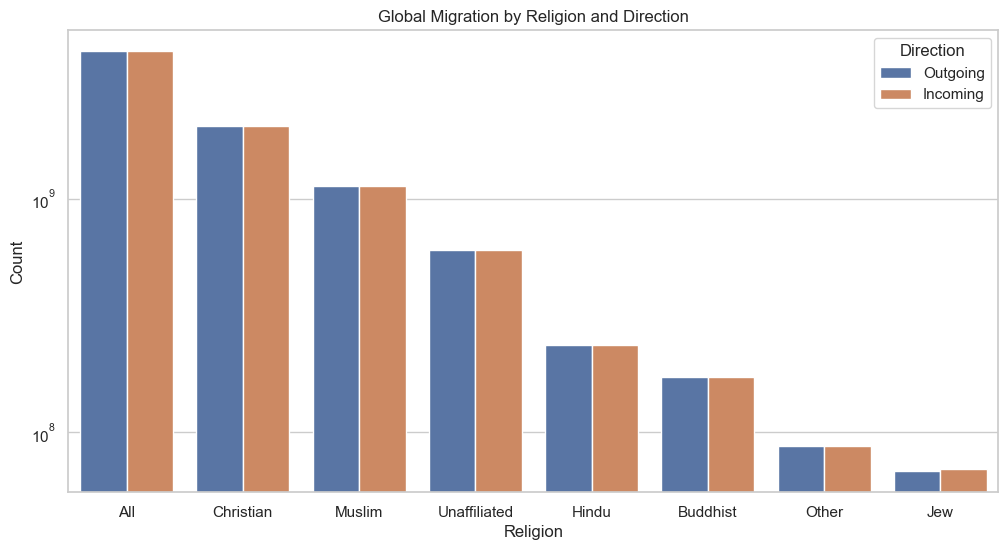

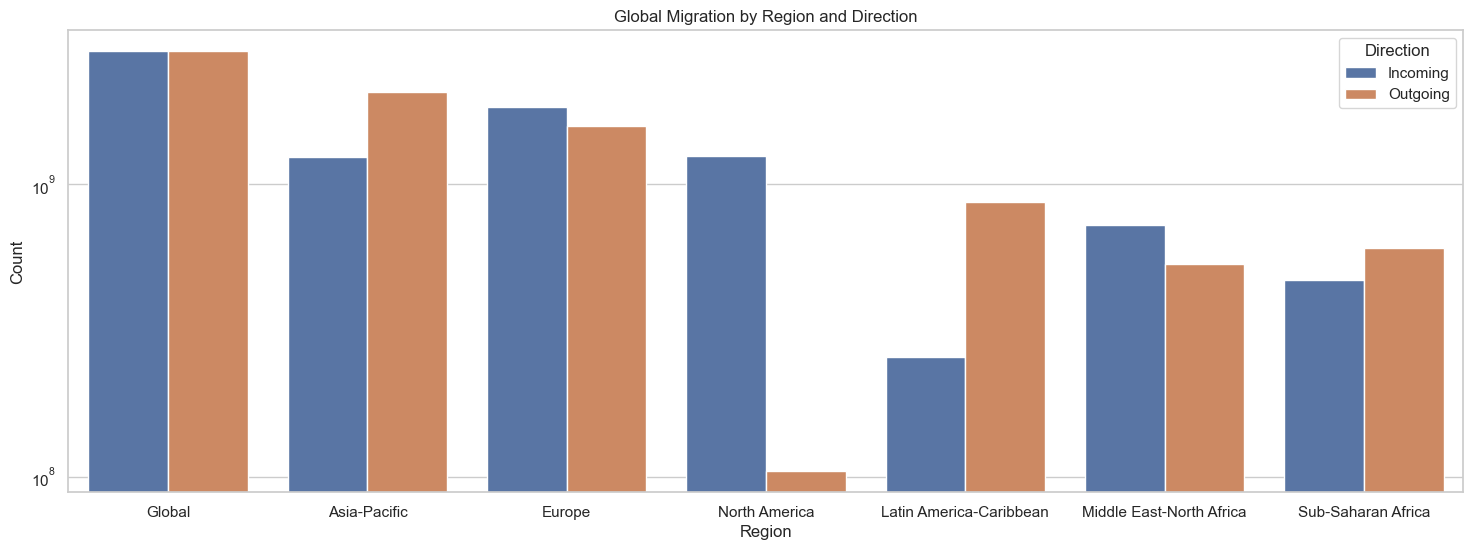

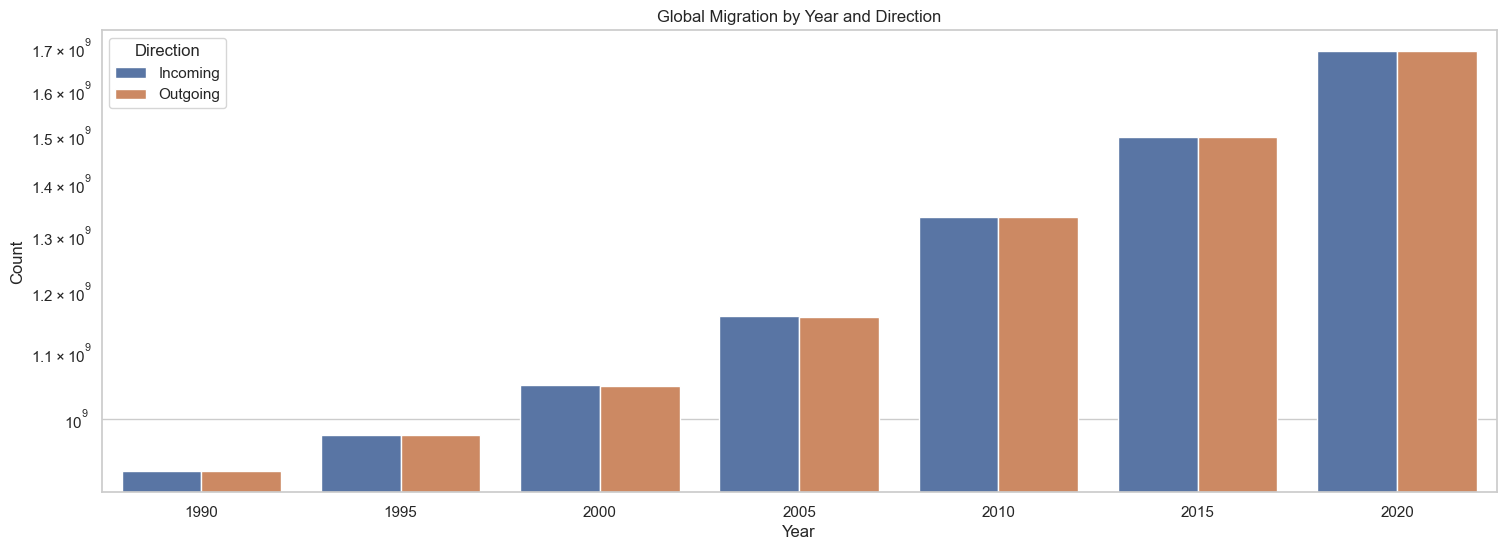

In [19]:
# Create one or more visualizations
plt.figure(figsize=(12, 6))
sns.barplot(data=religion_summary, x='Religion', y='Count', hue='Direction')
plt.title('Global Migration by Religion and Direction')
plt.yscale('log')
plt.legend(title='Direction')
plt.show()

plt.figure(figsize=(18, 6))
sns.barplot(data=region_summary, x='Region', y='Count', hue='Direction')
plt.title('Global Migration by Region and Direction')
plt.yscale('log')
plt.legend(title='Direction')
plt.show()

plt.figure(figsize=(18, 6))
sns.barplot(data=year_summary, x='Year', y='Count', hue='Direction')
plt.title('Global Migration by Year and Direction')
plt.yscale('log')
plt.legend(title='Direction')
plt.show()

In the barplots for global migration by religion and direction, we see that the count of incoming and outgoing migrants is the same for each religion, which obviously makes sense. If someone leaves one place, they would have to arrive somewhere else. This is also the case for the barplot of global migration by year. We can see that there is a large discrepancy in North America, with significantly more migrants entering North America versus leaving. This could warrant additional investigation. Both Europe and Asia-Pacific see large counts in both incoming and outgoing migrants. Asia has slightly more outgoing migrants, whereas Europe has slightly more incoming migrants. Additionally, as the years increase, the number of migrants also increases. 2020 shows the highest count of migrants and 1990 shows the lowest count.

## Q2.2 (10%): Total Migrant Counts by Region, Direction, and Religion — 1990 (Excluding Global)

The total migrant counts by region, direction, and religion in the year 1990. 1990 is the year with the smallest number of migrants in the dataset.

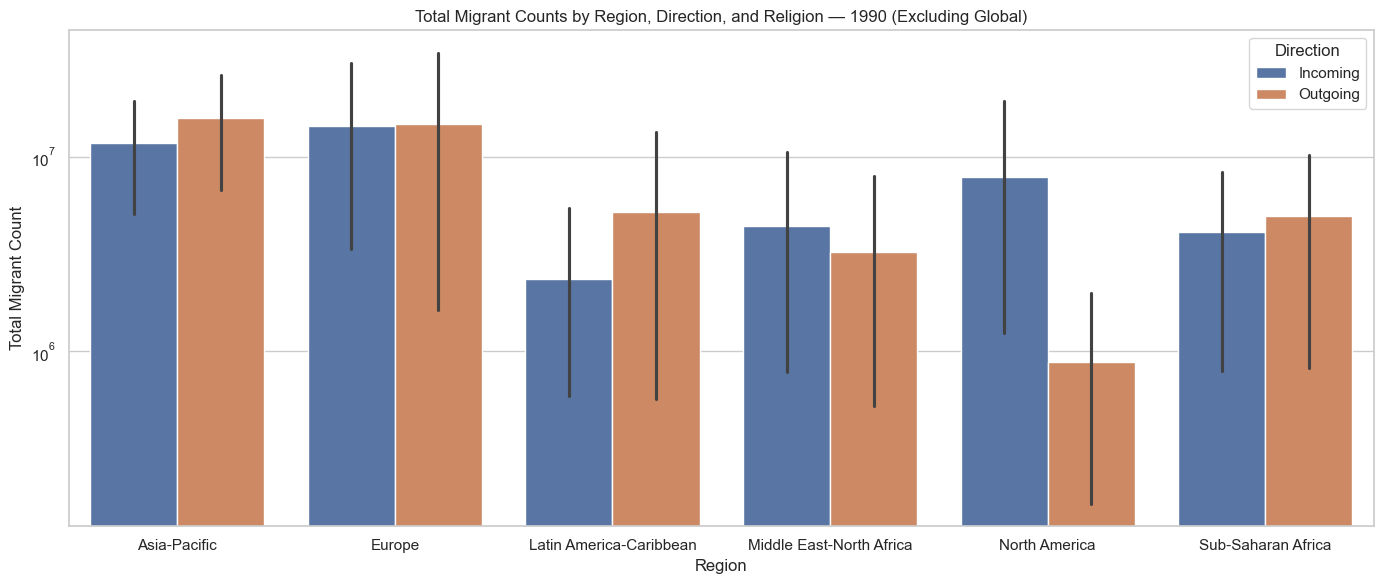

In [29]:
# your Q2.2 visualization code should be included here 
# make sure to execute it, so we can see your plot in the submitted pdf
migrant_data_1990 = migrant_data.copy()
migrant_data_1990 = migrant_data_1990[
    (migrant_data_1990['Region'] != 'Global') &
    (migrant_data_1990['Religion'] != 'All') &
    (migrant_data_1990['Year'] == 1990)
].copy()

grouped_1990 = migrant_data_1990.groupby(['Direction', 'Region', 'Religion'], as_index=False)['Count'].sum()

plt.figure(figsize=(14, 6))
sns.barplot(
    data=grouped_1990,
    x='Region',
    y='Count',
    hue='Direction'
)
plt.yscale('log')
plt.title('Total Migrant Counts by Region, Direction, and Religion — 1990 (Excluding Global)')
plt.xlabel('Region')
plt.ylabel('Total Migrant Count')
plt.legend(title='Direction')
plt.tight_layout()
plt.show()

## Q2.3 (10%): Total Migrant Counts by Region, Direction, and Religion — 2020 (Excluding Global)

The total migrant counts by region, direction, and religion in the year 2020. 2020 is the year with the largest number of migrants in the dataset.

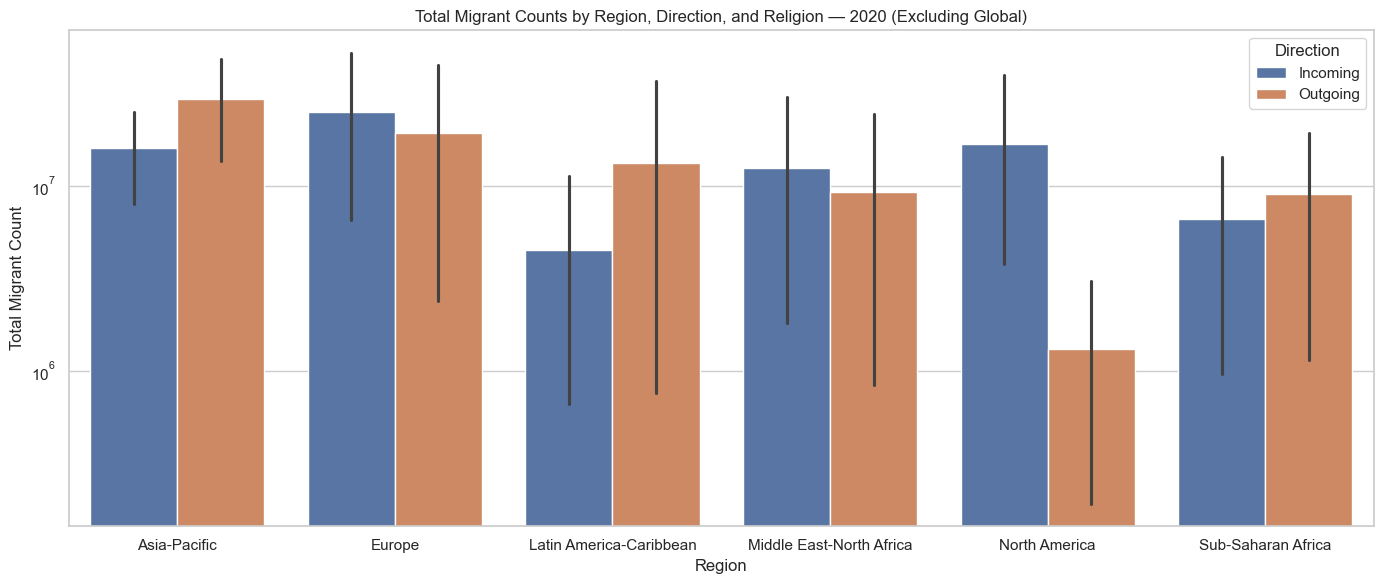

In [30]:
# your Q2.3 visualization code should be included here 
# make sure to execute it, so we can see your plot in the submitted pdf
migrant_data_2020 = migrant_data.copy()
migrant_data_2020 = migrant_data_2020[
    (migrant_data_2020['Region'] != 'Global') &
    (migrant_data_2020['Religion'] != 'All') &
    (migrant_data_2020['Year'] == 2020)
].copy()

grouped_2020 = migrant_data_2020.groupby(['Direction', 'Region', 'Religion'], as_index=False)['Count'].sum()

plt.figure(figsize=(14, 6))
sns.barplot(
    data=grouped_2020,
    x='Region',
    y='Count',
    hue='Direction'
)
plt.yscale('log')
plt.title('Total Migrant Counts by Region, Direction, and Religion — 2020 (Excluding Global)')
plt.xlabel('Region')
plt.ylabel('Total Migrant Count')
plt.legend(title='Direction')
plt.tight_layout()
plt.show()

## Q2.4 (10%): Incoming vs Outgoing Migrants by Religion — North America

Incoming and outgoing migration data across all years for the region North America. North America is the region that saw the highest difference between incoming and outgoing migration.

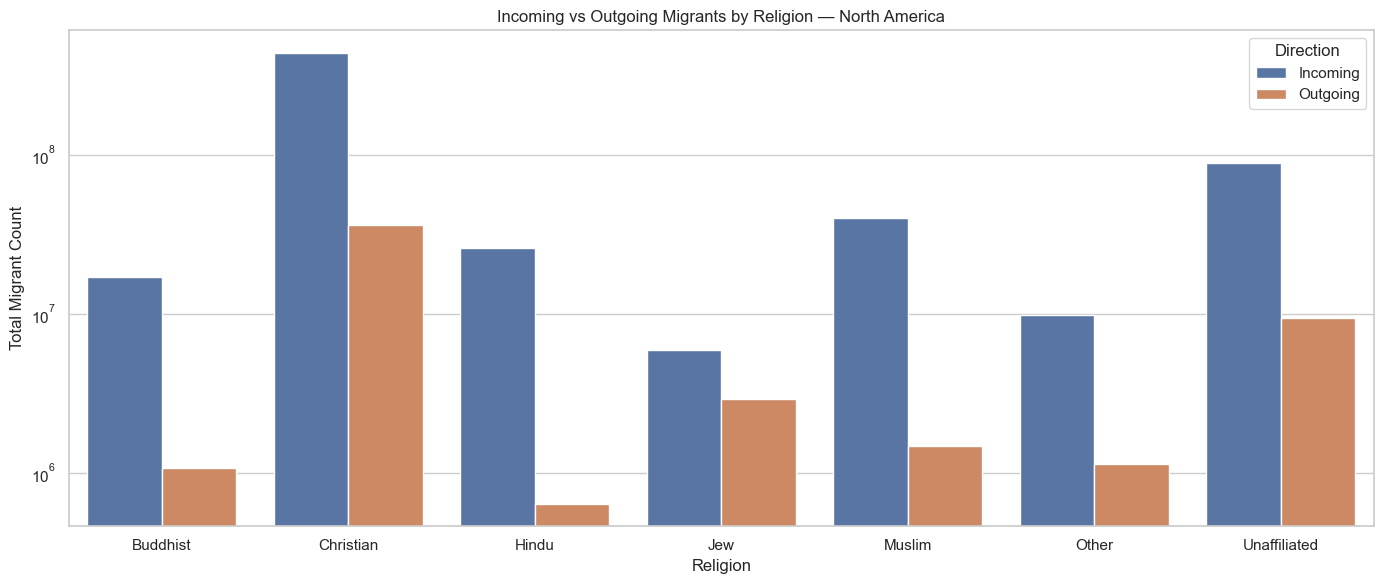

In [35]:
# your Q2.4 visualization code should be included here 
# make sure to execute it, so we can see your plot in the submitted pdf
migrant_data_north_america = migrant_data.copy()
migrant_data_north_america = migrant_data_north_america[
    (migrant_data_north_america['Region'] == 'North America') &
    (migrant_data_north_america['Religion'] != 'All')
].copy()

grouped_north_america = migrant_data_north_america.groupby(['Direction', 'Religion'], as_index=False)['Count'].sum()

plt.figure(figsize=(14, 6))
sns.barplot(
    data=grouped_north_america,
    x='Religion',
    y='Count',
    hue='Direction'
)
plt.yscale('log')
plt.title('Incoming vs Outgoing Migrants by Religion — North America')
plt.xlabel('Religion')
plt.ylabel('Total Migrant Count')
plt.legend(title='Direction')
plt.tight_layout()
plt.show()

# Extra Credit (15%)

The best 10 visualizations and insights from Questions 2.2 to 2.4 will get an extra 15% credit (at most one visualization can be considered per submission). In order to participate, do your best in the previous three questions and then mark the specific visualization you would like to participate with on Gradescope. We will showcase the best visualizations in class! 

This was the last part of Homework 2. Now you need to submit your work following the instructions in the beginning of the notebook and you are done!

# (10%) Part 3: Hypothesis testing 

### Let's experiment with Hypothesis testing. 

The goal is to test whether there is a difference in the two products' performance in the two conditions and recommend the better product.

Two products have been tested in two different experimental settings (or operating conditions) and the dataset is provided to you in p3c1.csv and p3c2.csv. Totally about 10000 tests were conducted.

An entry equal to 1 indicates that the product passed the test, and vice-versa.

Load the dataset first:


In [36]:
# Load datasets
df1 = pd.read_csv('p3c1.csv')

df2 = pd.read_csv('p3c2.csv')

print(df1.head(),'\n',df1.shape[0],'\n')

print(df2.head(),'\n',df2.shape[0],'\n')


   Unnamed: 0  prodA  prodB
0           0      0      0
1           1      0      0
2           2      0      1
3           3      0      1
4           4      0      1 
 10000 

   Unnamed: 0  prodA  prodB
0           0      0      1
1           1      0      0
2           2      1      0
3           3      0      0
4           4      0      0 
 10000 



## (6% points) Q3.1 We will create or write a function that takes in two samples and returns a p-value. 
I have given you the framework of this function. Note that ``norm.cdf(z) = P(Z < z)`` might be useful for calculating pvalue.

In [37]:
# 6 points for this function
def run_hypothesis_test(sampleA, sampleB):
    pA = sampleA.mean() 
    pB = sampleB.mean()

    nA = len(sampleA)
    nB = len(sampleB)

    pooled_prop = (sampleA.sum() + sampleB.sum()) / (nA + nB)
    
    zhat = (pA - pB) / ((pooled_prop * (1 - pooled_prop) * (1/nA + 1/nB)) ** 0.5)
    pvalue = 2 * (1 - norm.cdf(abs(zhat)))
    
    return pvalue   

### (2% points) Q3.2 Now run your function on a set of samples from p3c1 and p3c2 and interpret the output. 

Clearly state the null hypothesis, pvalues of the two conditions and mention in which of the two conditions viz., c1 and c2, do you accept and reject null hypothesis. Which one is the better product?

In [38]:
# code to extract resuls of the two products from each condition
sampleA_1 = df1["prodA"]
sampleB_1 = df1["prodB"]

sampleA_2 = df2["prodA"]
sampleB_2 = df2["prodB"]

pvalue_1 = run_hypothesis_test(sampleA_1, sampleB_1)
pvalue_2 = run_hypothesis_test(sampleA_2, sampleB_2)
print(pvalue_1, pvalue_2)
print(sampleA_2.mean(), sampleB_2.mean())

0.09710647574699616 0.0008853704943030394
0.2079 0.2273


H0: There is no difference in performance between product A and product B. P_A = P_B

H1: There is a difference is performance between product A and product B. P_A != P_B

Condition 1 p-value: 0.09710647574699616

Condition 2 p-value: 0.0008853704943030394

In condition 1, the p-value is greater than 0.05. Therefore, we do not reject H0. Based on condition 1, there is not enough evidence to confirm a statistically significant difference between the performances of product A and product B.

In condition 2, the p-value is less than 0.05. Therefore, we reject H0. Based on condition 2, there is enough evidence to conclude that there is a statistically significant difference between the performances of product A and product B.

Based on the samples taken in the second condition, product B is the better product.

## (2% points) Q3.3 Run the analysis using your function 200 times by taking a subsample of 1000 results from each condition, how do your p-values vary?

Follow these directions: 

1. Since the order does not matter, you may sample each column of the individual dataframes separately. For this, ``pandas.DataFrame.sample`` function might be useful. 

    Calling the function ``pandas.DataFrame.sample`` with n=1000 gives you one subsample. You have to do this for each column of the two dataframes separately for 200 times.

2. Using subsample of the two products from each condition,  compute p-value using above function and append.



Create a histogram of pvalues from each run above. What do you notice?

0.4702858096325705 0.3398020380623187


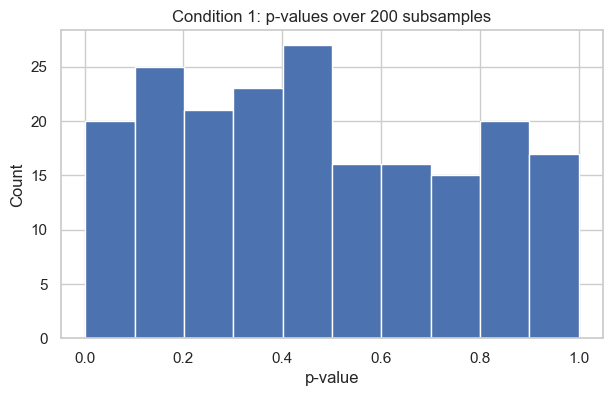

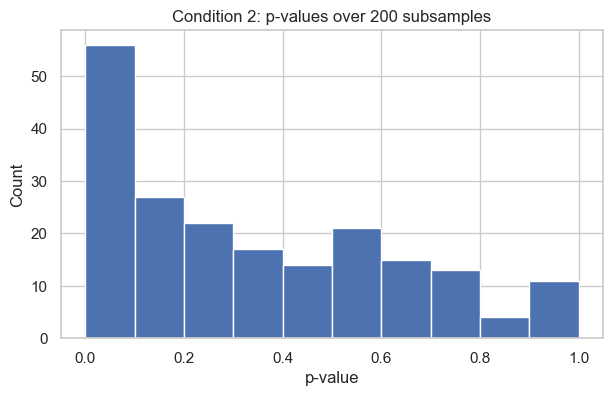

In [39]:
def subsample_pvalues(df, n=1000, runs=200):
    pvalues = []
    for _ in range(runs):
        a = df["prodA"].sample(n=n, replace=False)
        b = df["prodB"].sample(n=n, replace=False)
        pvalues.append(run_hypothesis_test(a, b))
    return np.array(pvalues)

pvals_c1 = subsample_pvalues(df1, n=1000, runs=200)
pvals_c2 = subsample_pvalues(df2, n=1000, runs=200)

print(pvals_c1.mean(), pvals_c2.mean())

plt.figure(figsize=(7,4))
plt.hist(pvals_c1)
plt.title("Condition 1: p-values over 200 subsamples")
plt.xlabel("p-value")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(7,4))
plt.hist(pvals_c2)
plt.title("Condition 2: p-values over 200 subsamples")
plt.xlabel("p-value")
plt.ylabel("Count")
plt.show()

Condition 1 contains significantly more samples with large p-values (values greater than 0.05) than condition 2. However, both condition 1 and condition 2 contain a significant number of samples with large p-values. Both the mean p-value of condition 1 and condition 2 is greater than 0.05. This suggests that there actually is not any significant difference between the performance of product A and product B.